<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br><br><br>

# Listed Volatility and Variance Derivatives

**Wiley Finance (2017)**

Dr. Yves J. Hilpisch | The Python Quants GmbH

http://tpq.io | [@dyjh](http://twitter.com/dyjh) | http://books.tpq.io

<img src="https://hilpisch.com/images/lvvd_cover.png" alt="Listed Volatility and Variance Derivatives" width="30%" align="left" border="0">

# Advanced Modeling of the VSTOXX Index

## Introduction

This chapter is a bit different in style compared to the other chapters about the VSTOXX volatility index and related derivatives. It introduces another, parsimonious model, which is called square-root jump diffusion (SRJD) to model the VSTOXX volatility index. The model, which is essentially an extension of the Gruenbichler and Longstaff (1996) model as analyzed in the previous chapter, is capable of reproducing prices of European options written on the VSTOXX reasonably well.

Two major enhancements characterize the SRJD model:

* **term structure**: it allows to capture the term structure as observed in the prices of futures on the VSTOXX index
* **jump component**: including a jump component allows to better replicate option prices in the short term

Adding these two components makes a market-consistent calibration of the model to a comprehensive set of European options on the VSTOXX index possible. For similar analyses and modeling approaches including jumps for the volatility index refer, for example, to Psychoyios (2005), Sepp (2008) or Psychoyios et al. (2010).

## Market Quotes for Call Options

Before we introduce the model, let us set the stage by revisiting market quotes for European call options written on the VSTOXX volatility index. First, we import the data.

In [1]:
import numpy as np
import pandas as pd
np.set_printoptions(suppress=True)
path = './data/'
h5 = pd.HDFStore(path + 'vstoxx_data_31032014.h5', 'r')

We have both options data and futures data stored in this file with quotes from 31. March 2014.

In [2]:
h5

<class 'pandas.io.pytables.HDFStore'>
File path: ./data/vstoxx_data_31032014.h5

Option market quotes are what we are concerned with for the moment.

In [3]:
option_quotes = h5['options_data']
option_quotes['DATE'] = pd.to_datetime(option_quotes['DATE'])
option_quotes['MATURITY'] = pd.to_datetime(option_quotes['MATURITY'])
option_quotes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 395 entries, 46170 to 46564
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DATE       395 non-null    datetime64[ns]
 1   EXP_YEAR   395 non-null    int64         
 2   EXP_MONTH  395 non-null    int64         
 3   TYPE       395 non-null    object        
 4   STRIKE     395 non-null    float64       
 5   PRICE      395 non-null    float64       
 6   MATURITY   395 non-null    datetime64[ns]
 7   TTM        395 non-null    float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(1)
memory usage: 27.8+ KB


In [4]:
option_quotes.head()

,DATE,EXP_YEAR,EXP_MONTH,TYPE,STRIKE,PRICE,MATURITY,TTM
46170,2014-03-31,2014,4,C,1.0,16.85,2014-04-18,0.049
46171,2014-03-31,2014,4,C,2.0,15.85,2014-04-18,0.049
46172,2014-03-31,2014,4,C,3.0,14.85,2014-04-18,0.049
46173,2014-03-31,2014,4,C,4.0,13.85,2014-04-18,0.049
46174,2014-03-31,2014,4,C,5.0,12.85,2014-04-18,0.049


At any given point in time, there are options on the VSTOXX available for eight maturities.

In [5]:
mats = sorted(set(option_quotes['MATURITY']))
mats

[Timestamp('2014-04-18 00:00:00'),
 Timestamp('2014-05-16 00:00:00'),
 Timestamp('2014-06-20 00:00:00'),
 Timestamp('2014-07-18 00:00:00'),
 Timestamp('2014-08-15 00:00:00'),
 Timestamp('2014-09-19 00:00:00'),
 Timestamp('2014-10-17 00:00:00'),
 Timestamp('2014-11-21 00:00:00')]

The spot level of the VSTOXX index on 31. March 2014 has been 17.6639. 

In [6]:
v0 = 17.6639

In what follows, we only want to plot call option market quotes which are not too far in-the-money nor out-of-the-money.

In [7]:
tol = 0.4
to_plot = option_quotes[(option_quotes['STRIKE'] > (1 - tol) * v0)
                      & (option_quotes['STRIKE'] < (1 + tol) * v0)]

The following figure shows the VSTOXX European call option quotes which fulfill the requirements. The goal of this chapter is to replicate "all these option quotes" as good as possible.

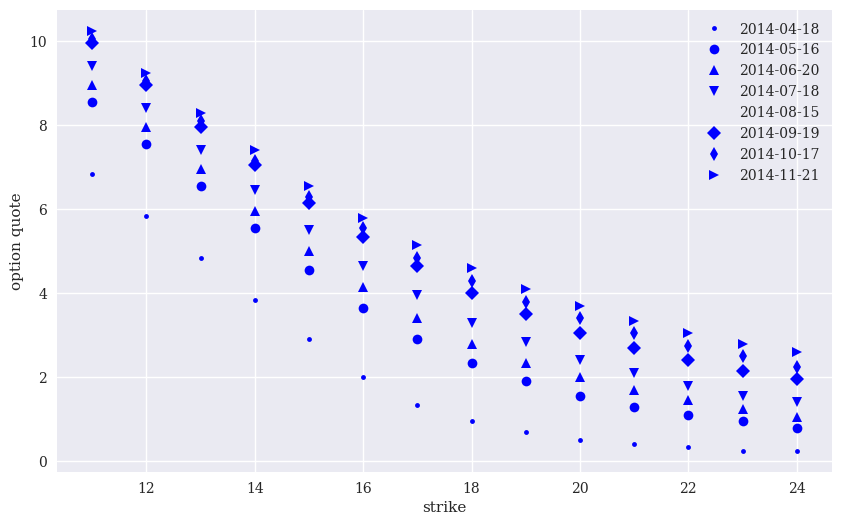

In [8]:
from pylab import mpl, plt
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
markers = ['.', 'o', '^', 'v', 'x', 'D', 'd', '>', '<']
plt.figure(figsize=(10, 6));
for i, mat in enumerate(mats):
    strikes = to_plot[(to_plot['MATURITY'] == mat)]['STRIKE']
    prices = to_plot[(to_plot['MATURITY'] == mat)]['PRICE']
    plt.plot(strikes, prices, 'b%s' % markers[i], label=str(mat)[:10])
plt.legend();
plt.xlabel('strike');
plt.ylabel('option quote');

<p style="font-family: monospace;">VSTOXX European call option quotes on 31. March 2014.

## The SRJD Model

Given is a filtered probability space $\{\Omega,\mathcal{F},\mathbb{F},P\}$ representing uncertainty in the model economy with final date $T$ where $0<T<\infty$. $\Omega$ denotes the continuous state space, $\mathcal{F}$ a $\sigma-$algebra, $\mathbb{F}$ a filtration &mdash; i.e. a family of non-decreasing $\sigma-$algebras $\mathbb{F}\equiv\{\mathcal{F}_{t\in [0,T]}\}$ with $\mathcal{F}_{0}\equiv\{\emptyset,\Omega\}$ and $\mathcal{F}_{T}\equiv \mathcal{F}$ &mdash; and $P$ the real or objective probability measure.

In the SRJD model, which is an affine jump diffusion (see Duffie et al. (2000)), the risk-neutral dynamics of the VSTOXX volatility index are given by the following stochastic differential equation (SDE)


$$\begin{equation*}
dv_{t}=\kappa (\theta -v_{t})dt+\sigma \sqrt{v_{t}}dZ_{t} + J_{t} v_{t} dN_{t}  -r_{J}dt
\end{equation*}$$


The meaning of the variables and parameters is

* $v_{t}$ volatility index level at date $t$
* $\kappa$ speed of adjustment of $v_{t}$ to ...
* ... $\theta$, the long-term mean of the index
* $\sigma$ volatility coefficient of the index level
* $Z_{t}$ standard Brownian motion
* $J_{t}$ jump at date $t$ with distribution ...
* ... $\log(1+J_{t})\approx \mathbf{N}\left(\log(1+\mu)-\frac{\delta^{2}}{2},\delta^{2}\right)$
* $\mathbf{N}$ cumulative distribution function of a standard normal random variable
* $N_{t}$ Poisson process with intensity $\lambda$
* $r_{J}\equiv \lambda \cdot \left(e^{\mu + \delta^{2}/2}-1\right)$ drift correction for jump

The stochastic process for $v$ is adapted to the filtration $\mathbb{F}$. Moreover, $Z$ and $N$ are not correlated. The time $t$ value of a zero-coupon bond paying one unit of currency at $T,0\leq t < T,$ is $B_{t}(T) = e^{-r(T-t)}$ with $r \geq 0$ the constant risk-less short rate. 

By the Fundamental Theorem of Asset Pricing, the time $t$ value of an attainable, $\mathcal{F}_{T}-$measurable contingent claim $V_{T}\equiv h_{T}(X_{T})\geq 0$ (satisfying suitable integrability conditions) is given by arbitrage as

\begin{equation*}
V_{t}=\mathbf{E}^{Q}_{t}\left( B_{t}(T) V_{T} \right)
\end{equation*}

with $V_{0}=\mathbf{E}^{Q}_{0}\left( B_{0}(T) V_{T} \right)$ as the important special case for valuation purposes. $Q$ is a $P-$equivalent martingale measure. The contingent claim could be a European call option maturing at $T$ with payoff $V_T = h_{T}(v_{T})\equiv\max[v_{T}-K,0]$. It could also be a European put with payoff $V_T = h_{T}(v_{T})\equiv\max[K-v_{T},0]$. In both cases, $K$ is the fixed strike price of the option. 

To simulate the financial model, i.e. to generate numerical values for $v_{t}$, it has to be discretized. To this end, divide the given time interval $[0,T]$ in equidistant sub-intervals $\Delta t$ such that now $t \in \{0,\Delta t,2 \Delta t, ..., T\}$, i.e. there are $M+1$ points in time with $M\equiv T/\Delta t$. With $s=t-\Delta t$, a discretization of the continuous time market model is given by 

$$\begin{eqnarray*}
\tilde{v}_{t} &=& \tilde{v}_{s} + \kappa(\theta-\tilde{v}_{s}^{+}) \Delta t + \sigma\sqrt{\tilde{v}_{s}^{+}} \sqrt{\Delta t}z^1_{t} \nonumber \\
&+& \left(e^{\mu_{J}+\delta^{2}z^{2}_{t}}-1\right) \tilde{v}_{s}^+ y_{t} -r_J \Delta t \\
v_{t} &=& \tilde{v}_{t}^{+} 
\end{eqnarray*}$$

for $t \in \{\Delta t, ..., T\}$ with $x^+\equiv\max[x,0]$ and the $z^{n}_{t}$ being standard normally distributed and $y_t$ Poisson distributed. $z^{1}_{t}, z^{2}_{t}$ and $y_t$ are uncorrelated. This discretization scheme is an Euler discretization and is generally called *full trunction* scheme. See Lord et al. (2008) for an analysis of this and other biased discretization schemes for the square-root diffusion process.

## Term Structure Calibration

The first in the  calibration of the SRJD model, is with regard to the futures term structure.

### Futures Term Structure

It is difficult for parsimonious short rate models like Cox et al. (1985) to account for different term structures of the interest rate. A possible solution is the introduction of time-dependent parameters which, however, enlarges the number of parameters significantly, sacrificing at the same time the convenience of a limited number of economic parameters. Another solution is a *deterministic shift approach* according to Brigo and Mercurio (2001) which preserves the basic structure of the model with all its advantages and which nevertheless allows to better account for different term structures of the short rate.

In this section, we transfer the deterministic shift approach for short rate models of Brigo and Mercurio (2001) to the SRJD model. Since the square-root diffusion and the jumps are not correlated, we can first apply the approach to the diffusion part and use this enhanced component later on in conjunction with the jump component.

Before we present the theory, a look at the VSTOXX futures data first.

In [9]:
futures_quotes = h5['futures_data']
futures_quotes['DATE'] = pd.to_datetime(futures_quotes['DATE'])
futures_quotes['MATURITY'] = pd.to_datetime(futures_quotes['MATURITY'])
futures_quotes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, 496 to 503
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DATE       8 non-null      datetime64[ns]
 1   EXP_YEAR   8 non-null      int64         
 2   EXP_MONTH  8 non-null      int64         
 3   PRICE      8 non-null      float64       
 4   MATURITY   8 non-null      datetime64[ns]
 5   TTM        8 non-null      float64       
dtypes: datetime64[ns](2), float64(2), int64(2)
memory usage: 448.0 bytes


The following figure presents the futures quotes for all eight maturities.

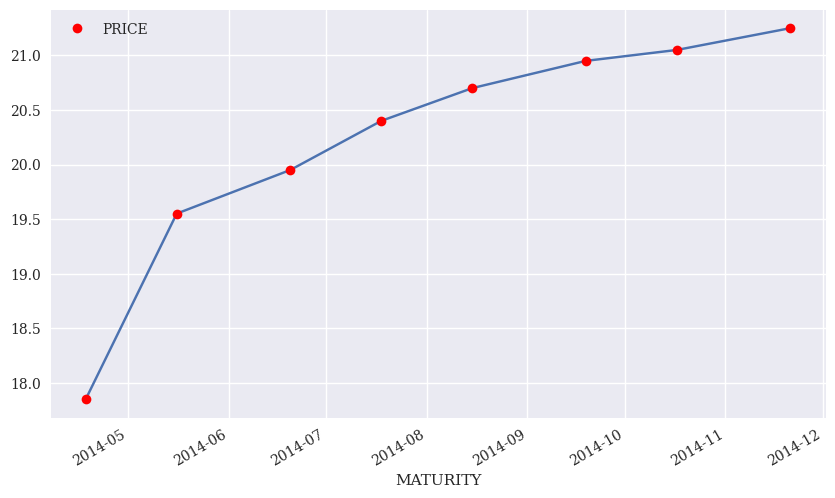

In [10]:
ax = futures_quotes.plot(x='MATURITY', y='PRICE',
                         figsize=(10, 6), legend=False)
futures_quotes.plot(x='MATURITY', y='PRICE', style='ro', ax=ax);

<p style="font-family: monospace;">VSTOXX futures quotes on 31. March 2014.

Consider for now the square-root diffusion volatility model of Gruenbichler and Longstaff (1996) as presented in the previous chapter, which is formally the same as the short rate model of Cox et al. (1985) and which is a special case of the SRJD model

\begin{equation*}
dv_t = \kappa (\theta -v_{t})dt + \sigma \sqrt{v_{t}}dZ_{t}
\end{equation*}

We want to calibrate this model to the observed volatility term structure, given by the above presented set of prices for futures on the VSTOXX index with different maturities. We have to minimize for all considered times $t$ and a parameter set $\alpha = (\kappa,\theta,\sigma,v_{0})$ simultaneously the single differences

\begin{equation*}
\Delta f(0,t) \equiv f(0,t)-f^{GL96}(0,t;\alpha)
\end{equation*}

where $f(0,t)$ is the time $0$ market (instantaneous) forward volatility for time $t$ and the quantity $f^{GL96}(0,t;\alpha)$ is the model (instantaneous) forward volatility for time $t$ given parameter set $\alpha$.

Assume that there is a continuously differentiable volatility term structure function $F(0,t)$ available (i.e. there are infinitely many volatility futures prices). The forward volatility then is

\begin{equation*}
f(0,t)=\frac{\partial F(0,t)}{\partial t}
\end{equation*}

On the other hand, the model implied forward volatility is given as (see Brigo and Mercurio (2001))

\begin{eqnarray*}
f^{GL96}(0,t;\alpha) = \frac{\kappa \theta\left(e^{\gamma t}-1\right)}{2\gamma+(\kappa+\gamma)\left(e^{\gamma t}-1\right)} \nonumber \\
+v_{0} \frac{4 \gamma ^{2} e^{\gamma t}}{\left(2\gamma+(\kappa+\gamma)\left(e^{\gamma t}-1\right)\right)^{2}} 
\end{eqnarray*}

with

\begin{equation*}
\gamma \equiv \sqrt{\kappa^{2}+2\sigma^{2}}
\end{equation*}

The Python script ``srjd_fwd_calibration.py`` contains the Python code to calibrate the forward volatilities to the VSTOXX futures prices (see the appendix for the complete script). The beginning of the script is about library imports, importing the data sets and making some selections.

In [11]:
!sed -n 8,28p scripts/srjd_fwd_calibration.py

import math
import numpy as np
import pandas as pd
import scipy.optimize as sco

v0 = 17.6639  # initial VSTOXX index level
i = 0  # counter for calibration runs

# reading the VSTOXX futures quotes
path = './data/'
h5 = pd.HDFStore(path + 'vstoxx_data_31032014.h5', 'r')
futures_quotes = h5['futures_data']
h5.close()

# selecting needed data columns and adding spot value
forwards = list(futures_quotes['PRICE'].values)
forwards.insert(0, v0)
forwards = np.array(forwards)
ttms = list(futures_quotes['TTM'].values)
ttms.insert(0, 0)
ttms = np.array(ttms)


The function ``srd_forwards()`` implements the forward formula from above for a given parameter set. 

In [12]:
import sys
sys.path.append('scripts')

In [13]:
import srjd_fwd_calibration as srjdf

In [14]:
srjdf.srd_forwards??

Signature: srjdf.srd_forwards(p0)
Source:   
def srd_forwards(p0):
    ''' Function for forward volatilities in GL96 Model.

    Parameters
    p0: list
        set of model parameters, where

        kappa: float
            mean-reversion factor
        theta: float
            long-run mean
        sigma: float
            volatility factor

    Returns
    forwards: NumPy ndarray object
        forward volatilities
    '''
    t = ttms
    kappa, theta, sigma = p0
    g = math.sqrt(kappa ** 2 + 2 * sigma ** 2)
    sum1 = ((kappa * theta * (np.exp(g * t) - 1)) /
            (2 * g + (kappa + g) * (np.exp(g * t) - 1)))
    sum2 = v0 * ((4 * g ** 2 * np.exp(g * t)) /
                 (2 * g + (kappa + g) * (np.exp(g * t) - 1)) ** 2)
    forwards = sum1 + sum2
    return forwards
File:      ~/data/projects/lvvd/code/scripts/srjd_fwd_calibration.py
Type:      function

To operationalize the calibration, we use the mean squared error (MSE) as our yardstick

\begin{equation*}
\min_{\alpha } \frac{1}{N} \sum_{n=1}^{N}\left( f_{n} - f_{n}^{GL96}(\alpha )\right)^{2}
\end{equation*}

which is to be minimized. Here, we assume that we have $N$ observations for the forward volatility. In Python this takes on the form of function ``srd_fwd_error()``.

In [15]:
srjdf.srd_fwd_error??

Signature: srjdf.srd_fwd_error(p0)
Source:   
def srd_fwd_error(p0):
    ''' Error function for GL96 forward volatilities calibration.

    Parameters
    p0: tuple
        parameter vector

    Returns
    MSE: float
        mean-squared error for p0
    '''
    global i
    kappa, theta, sigma = p0
    srd_fwds = srd_forwards(p0)
    MSE = np.sum((forwards - srd_fwds) ** 2) / len(forwards)
    if 2 * kappa * theta < sigma ** 2:
        MSE = MSE + 100   # penalty
    elif sigma < 0:
        MSE = MSE + 100
    # print intermediate results: every 50th iteration
    if i % 50 == 0:
        print("{:6.3f} {:6.3f} {:6.3f}".format(*p0) + "{:>12.5f}".format(MSE))
    i += 1
    return MSE
File:      ~/data/projects/lvvd/code/scripts/srjd_fwd_calibration.py
Type:      function

Executing the script yields optimal parameters for the Gruenbichler and Longstaff (1996) model given the VSTOXX futures prices.

In [16]:
%run scripts/srjd_fwd_calibration.py

 1.000 17.500  1.000    35.99817
 0.258 40.585  0.057     5.61895
 1.575 46.996  0.392     0.22958
 2.525 46.207  0.710     0.06348
 3.447 44.752  0.972     0.04264
 3.538 44.458  0.903     0.04261
 3.947 43.495  0.610     0.04243
 4.113 43.102  0.275     0.04219
 4.187 42.969  0.019     0.04213
 4.169 42.984  0.002     0.04213
 4.170 42.984  0.000     0.04213
Optimization terminated successfully.
         Current function value: 0.042129
         Iterations: 292
         Function evaluations: 526


In [17]:
opt.round(3)

array([ 4.17 , 42.984,  0.   ])

These optimal values can be used to calculate the model forward volatilities using function ``srd_forwards()``.

In [18]:
from srjd_fwd_calibration import *
srd_fwds = srd_forwards(opt)
srd_fwds

array([17.6639    , 18.37130183, 19.22831373, 19.97504105, 20.3916346 ,
       20.69048824, 20.95488999, 21.10239774, 21.23092346])

The numerical differences to the market futures prices are:

In [19]:
srd_fwds - forwards

array([ 0.        ,  0.52130183, -0.32168627,  0.02504105, -0.0083654 ,
       -0.00951176,  0.00488999,  0.05239774, -0.01907654])

The following figure compares the model futures prices (forward volatilities) with the VSTOXX futures market quotes. For longer maturities the fit is quite well.

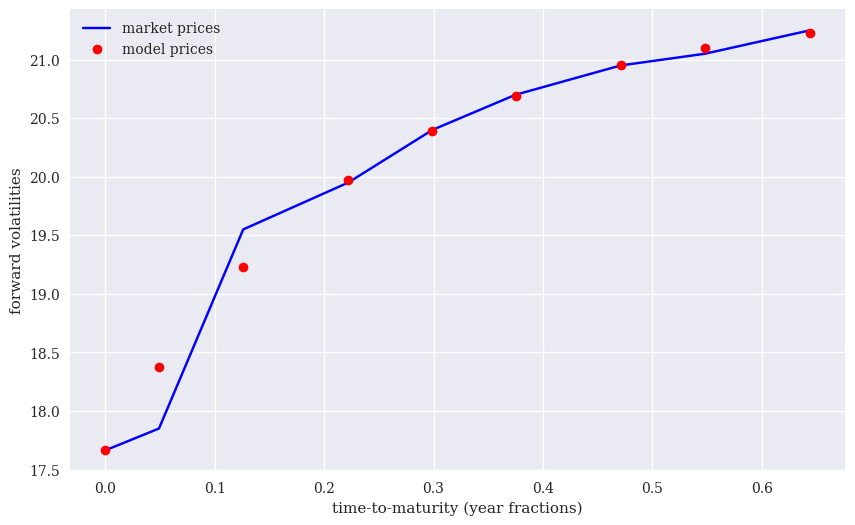

In [20]:
plt.figure(figsize=(10, 6));
plt.plot(ttms, forwards, 'b', label='market prices');
plt.plot(ttms, srd_fwds, 'ro', label='model prices');
plt.legend(loc=0);
plt.xlabel('time-to-maturity (year fractions)');
plt.ylabel('forward volatilities');

<p style="font-family: monospace;">VSTOXX futures market quotes vs. model prices.

Finally, we save the results from the term structure calibration for later use during the simulation of the model.

In [21]:
import pickle
f = open('varphi', 'wb')  # open file on disk
## write ttms object and differences (varphi values) as dictionary
pickle.dump({'ttms': ttms, 'varphi': srd_fwds - forwards}, f)
f.close()  # close file

### Shifted Volatility Process

Assume that we are given a continuously differentiable futures price function (i.e. through splines interpolation of discrete futures prices for different maturities). We consider now the deterministically shifted volatility process (see Brigo and Mercurio (2001))

\begin{equation*}
\hat{v}_t \equiv v_t + \varphi(t,\alpha^*)
\end{equation*}

with $\varphi(t,\alpha^*) \equiv f(0,t)-f^{GL96}(0,t;\alpha^*)$, the difference at time $t$ between the market implied forward volatility and the model implied forward volatility after calibration, that is for the optimal parameter set $\alpha^*$. $\varphi(t,\alpha^*)$ corresponds to the differences (bars) in the following figure.

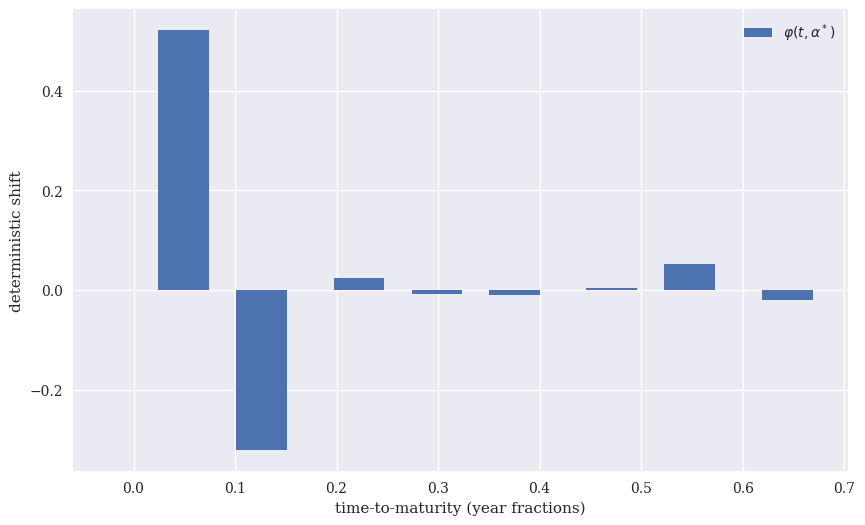

In [22]:
plt.figure(figsize=(10, 6));
plt.bar(ttms, srd_fwds - forwards,
            width=0.05, label='$\\varphi(t,\\alpha^*)$')
plt.legend(loc=0)
plt.xlabel('time-to-maturity (year fractions)')
plt.ylabel('deterministic shift');

<p style="font-family: monospace;">Deterministic shift values to account for VSTOXX futures term structure.

The SRJD model discretization can now be adjusted as follows:

\begin{eqnarray}
\tilde{v}_{t} &=& \tilde{v}_{s} + \kappa(\theta-\tilde{v}_{s}^{+}) \Delta t + \sigma\sqrt{\tilde{v}_{s}^{+}} \sqrt{\Delta t}z^1_{t} \nonumber \\
&+& \left(e^{\mu_{J}+\delta^{2}z^{2}_{t}}-1\right)  \tilde{v}_{s}^+ y_{t} -r_J \Delta t  \label{eq:disc3} \\
\hat{v}_{t} &=& \tilde{v}_{t}^{+} + \varphi(t,\alpha^*) \label{eq:disc4}
\end{eqnarray}

This is consistent since the diffusion and jump parts are not correlated and since the jump part is added in a way that the first moment of the stochastic volatility process does not change.

## Option Valuation by Monte Carlo Simulation

This section implements Monte Carlo simulation procedures for the SRJD model.

### Monte Carlo Valuation

In what follows, the model option values are computed by Monte Carlo simulation (MCS). Given the discrete version of the financial model, the value of a European call option on the volatility index is estimated by MCS as follows:

<img src="https://hilpisch.com/lvvd_algo.png" align="center">

$V_0$ is the MCS estimator for the European call option value.

### Technical Implementation

In view of using a numerical method like MCS for all valuation and calibration tasks, the parametrization and implementation of the MCS algorithm plays an important role. Some major features of our implementation are:

* **discretization**: the algorithm uses the Euler discretization scheme which is an approximation only but which might bring performance benefits
* **random numbers**: for every single option valuation the seed can be held constant such that every option is valued with the same set of (pseudo-) random numbers
* **variance reduction**: both antithetic variates and moment matching (for the first two moments of the pseudo-random numbers) are used as generic variance reduction techniques
* **deterministic shift**: the deterministic shift values $\varphi$ are determined only once through a separate calibration and are held constant afterwards (even if model parameters change)

$\varphi$ only has to be deterministic and integrable on closed intervals (see Brigo and Mercurio (2001)), which is of course the case. For the approach to be valid, it is not important how we came up with the $\varphi$ originally.

The Python code for simulating the SRJD model is found in the script ``srjd_simulation.py`` (see the appendix for the complete script). The beginning of the script shows several imports, the definition of example parameters and also the cubic splines interpolation to be used for the estimation of the deterministic shift parameters.

In [23]:
!sed -n 8,39p scripts/srjd_simulation.py

import math
import pickle
import numpy as np
import scipy.interpolate as scint

v0 = 17.6639  # initial VSTOXX index level

# parameters of square-root diffusion
kappa = 2.0  # speed of mean reversion
theta = 15.0  # long-term volatility
sigma = 1.0  # standard deviation coefficient

# parameters of log-normal jump
lamb = 0.4  # intensity (jumps per year)
mu = 0.4  # average jump size
delta = 0.1  # volatility of jump size

# general parameters
r = 0.01  # risk-free interest rate
K = 17.5  # strike
T = 0.5  # time horizon
M = 150  # time steps
I = 10000  # number of MCS paths
anti_paths = True  # antithetic variates
mo_match = True  # moment matching


# deterministic shift parameters
varphi = pickle.load(open('varphi', 'rb'))
tck = scint.splrep(varphi['ttms'], varphi['varphi'], k=1)
  # linear splines interpolation of
  # term structure calibration differences


The Python function ``random_number_gen()`` generates arrays of standard normally distributed pseudo-random numbers using both antithetic variates and moment matching as generic variance reduction techniques.

In [24]:
import srjd_simulation as srjds

In [25]:
srjds.random_number_gen??

Signature: srjds.random_number_gen(M, I, fixed_seed=False)
Source:   
def random_number_gen(M, I, fixed_seed=False):
    ''' Generate standard normally distributed pseudo-random numbers

    Parameters
    M: int
        number of time intervals
    I: int
        number of paths

    Returns
    ran: NumPy ndarrayo object
        random number array
    '''
    if fixed_seed is True:
        np.random.seed(10000)
    if anti_paths is True:
        ran = np.random.standard_normal((M + 1, int(I / 2)))
        ran = np.concatenate((ran, -ran), axis=1)
    else:
        ran = np.standard_normal((M + 1, I))
    if mo_match is True:
        ran = ran / np.std(ran)
        ran -= np.mean(ran)
    return ran
File:      ~/data/projects/lvvd/code/scripts/srjd_simulation.py
Type:      function

The major function of this script is ``srjd_simulation()`` which implements the Monte Carlo simulation for the SRJD model based on an Euler discretization scheme. The scheme used here is usually called *full truncation* scheme.

In [26]:
srjds.srjd_simulation??

Signature:
srjds.srjd_simulation(
    x0,
    kappa,
    theta,
    sigma,
    lamb,
    mu,
    delta,
    T,
    M,
    I,
    fixed_seed=False,
)
Source:   
def srjd_simulation(x0, kappa, theta, sigma,
                    lamb, mu, delta, T, M, I, fixed_seed=False):
    ''' Function to simulate square-root jump Difusion.

    Parameters
    x0: float
        initial value
    kappa: float
        mean-reversion factor
    theta: float
        long-run mean
    sigma: float
        volatility factor
    lamb: float
        jump intensity
    mu: float
        expected jump size
    delta: float
        standard deviation of jump
    T: float
        time horizon/maturity
    M: int
        time steps
    I: int
        number of simulation paths

    Returns
    x: NumPy ndarray object
        array with simulated SRJD paths
    '''
    dt = float(T) / M  # time interval
    shift = scint.splev(np.arange(M + 1) * dt, tck, der=0)
      # deterministic shift values
    xh = np.zeros((M

Finally, the function ``srjd_call_valuation()`` estimates the value of a European call option given the simulated volatility paths from ``srjd_simulation()``.

In [27]:
srjds.srjd_call_valuation??

Signature:
srjds.srjd_call_valuation(
    v0,
    kappa,
    theta,
    sigma,
    lamb,
    mu,
    delta,
    T,
    r,
    K,
    M=150,
    I=10000,
    fixed_seed=False,
)
Source:   
def srjd_call_valuation(v0, kappa, theta, sigma,
                        lamb, mu, delta, T, r, K, M=M, I=I,
                        fixed_seed=False):
    ''' Function to value European volatility call option in SRDJ model.
    Parameters see function srjd_simulation.

    Returns
    call_value: float
        estimator for European call present value for strike K
    '''
    v = srjd_simulation(v0, kappa, theta, sigma,
                        lamb, mu, delta, T, M, I, fixed_seed)
    call_value = np.exp(-r * T) * sum(np.maximum(v[-1] - K, 0)) / I
    return call_value
File:      ~/data/projects/lvvd/code/scripts/srjd_simulation.py
Type:      function

Executing the script yields a MCS estimator for the European call option with the parameters as assumed as in the script of about 1 currency unit.

In [28]:
%run scripts/srjd_simulation.py

Value of European call by MCS:     0.9976


## Model Calibration

This section now calibrates the SRJD model to market quotes for European call options on VSTOXX futures. It considers calibrations to a single maturity as well as to multiple maturities.

### The Python Code

The calibration of the SRJD model is similar to the procedure for the Gruenbichler and Lonstaff (1996) square-root diffusion model as presented in the previous chapter. The major difference now is that we have to take into account more parameter values for the optimization. The Python code is contained in script ``srjd_model_calibration.py`` (see the appendix for the complete script). As usual a few imports and parameter definitions first.

In [29]:
!sed -n 10,21p scripts/srjd_model_calibration.py

import numpy as np
import pandas as pd
import scipy.optimize as sco
import matplotlib.pyplot as plt
from srd_model_calibration import path, read_select_quotes
from srjd_simulation import srjd_call_valuation

# fixed parameters
r = 0.01  # risk-less short rate
v0 = 17.6639  # VSTOXX index at 31.03.2014
M = 15  # number of time intervals
I = 100  # number of simulated paths


In what follows, we want to calibrate the model simultaneously to multiple maturities for the VSTOXX European call options. The valuation function ``srjd_valuation_function()`` therefore now calculates the differences between model and market values directly and returns an array with all differences (relative or absolute).

In [30]:
import srjd_model_calibration as srjdc

In [31]:
srjdc.srjd_valuation_function??

Signature: srjdc.srjd_valuation_function(p0)
Source:   
def srjd_valuation_function(p0):
    ''' Valuation ('difference') function for all options
        of a given DataFrame object.

    Parameters
    p0: list
        set of model parameters

    Returns
    diffs: NumPy ndarray object
        array with valuation differences
    '''
    global relative, option_data
    kappa, theta, sigma, lamb, mu, delta = p0
    diffs = []
    for i, option in option_data.iterrows():
        value = srjd_call_valuation(v0, kappa, theta, sigma,
                                    lamb, mu, delta,
                                    option['TTM'], r, option['STRIKE'],
                                    M=M, I=I, fixed_seed=True)
        if relative is True:
            diffs.append((value - option['PRICE']) / option['PRICE'])
        else:
            diffs.append(value - option['PRICE'])
    diffs = np.array(diffs)
    return diffs
File:      ~/data/projects/lvvd/code/scripts/srjd_model_calibrati

The error function ``srjd_error_function()`` for the SRJD model has to be enhanced compared to the SRD case to account for the additional parameters of the model.

In [32]:
srjdc.srjd_error_function??

Signature: srjdc.srjd_error_function(p0)
Source:   
def srjd_error_function(p0):
    ''' Error function for model calibration.

    Parameters
    p0: tuple
        set of model parameters

    Returns
    MSE: float
        mean squared (relative/absolute) error
    '''
    global i, min_MSE, option_data
    OD = len(option_data)
    diffs = srjd_valuation_function(p0)
    kappa, theta, sigma, lamb, mu, delta = p0

    # penalties
    pen = 0.
    if 2 * kappa * theta < sigma ** 2:
        pen = 1000.0
    if kappa < 0 or theta < 0 or sigma < 0 or lamb < 0 or delta < 0:
        pen = 1000.0

    MSE = np.sum(diffs ** 2) / OD + pen  # mean squared error

    min_MSE = min(min_MSE, MSE)  # running minimum value

    if i == 0:
        print('\n' + ('{:>5s}'.format('its')
                      + '{:>7s} {:>6s} {:>6s} {:>6s} {:>6s} {:>6s}'.format(
            'kappa', 'theta', 'sigma', 'lamb', 'mu', 'delta')
            + '{:>12s}'.format('MSE') + '{:>12s}'.format('min_MSE')))
    # print

The same holds true for the calibration function ``srjd_model_calibration()`` itself. This function allows to select certain maturities for the the calibration.

In [33]:
srjdc.srjd_model_calibration??

Signature: srjdc.srjd_model_calibration(data, p0=None, rel=False, mats=None)
Source:   
def srjd_model_calibration(data, p0=None, rel=False, mats=None):
    ''' Function for global and local model calibration.

    Parameters
    option_data: pandas DataFrame object
        option quotes to be used
    relative: bool
        relative or absolute MSE
    mats: list
        list of maturities of option quotes to calibrate to

    Returns
    opt: tuple
        optimal parameter values
    '''
    global i, min_MSE, option_data
    global relative  # if True: MSRE is used, if False: MSAE

    min_MSE = 5000.  # dummy value
    relative = rel  # relative or absolute
    option_data = data

    if mats is not None:
        # select the option data for the given maturities
        option_data = option_data[option_data['MATURITY'].isin(mats)]

    # global optimization
    if p0 is None:
        i = 0  # counter for calibration iterations
        p0 = sco.brute(srjd_error_function, (
        

### Short Maturity

The addition of a jump component shall allow a better fit to short term call option market quotes. Therefore, consider the following calibration to the shortest option maturity available.

In [34]:
from srjd_model_calibration import *
## read option data, allow for 30% moneyness tolerance
option_data = read_select_quotes(tol=0.3)
option_data

,DATE,EXP_YEAR,EXP_MONTH,TYPE,STRIKE,PRICE,MATURITY,TTM
46182,2014-03-31,2014,4,C,13.0,4.85,2014-04-18,0.049315
46183,2014-03-31,2014,4,C,14.0,3.85,2014-04-18,0.049315
46184,2014-03-31,2014,4,C,15.0,2.90,2014-04-18,0.049315
46185,2014-03-31,2014,4,C,16.0,2.00,2014-04-18,0.049315
46186,2014-03-31,2014,4,C,17.0,1.35,2014-04-18,0.049315
...,...,...,...,...,...,...,...,...
46533,2014-03-31,2014,11,C,18.0,4.60,2014-11-21,0.643836
46534,2014-03-31,2014,11,C,19.0,4.10,2014-11-21,0.643836
46535,2014-03-31,2014,11,C,20.0,3.70,2014-11-21,0.643836
46536,2014-03-31,2014,11,C,21.0,3.35,2014-11-21,0.643836


In [35]:
%%time
opt_1 = srjd_model_calibration(option_data, p0=None,
                               rel=False, mats=['2014-4-18'])

/Users/tuan/data/projects/lvvd/code/scripts/srjd_model_calibration.py:123: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  option_data = option_data[option_data['MATURITY'].isin(mats)]



  its  kappa  theta  sigma   lamb     mu  delta         MSE     min_MSE
    0  1.000 10.000  1.000  0.000 -0.200  0.000     0.15785     0.15785
  100  1.000 20.000  3.000  0.800 -0.200  0.150     0.10276     0.01976
  200  5.000 20.000  3.000  0.400 -0.200  0.300     0.28256     0.01976
  300  9.000 20.000  3.000  0.000  0.100  0.000     0.70669     0.01976

  its  kappa  theta  sigma   lamb     mu  delta         MSE     min_MSE
    0  1.000 10.000  3.000  0.400 -0.200  0.000     0.01976     0.01976
  100  1.016  9.216  2.996  0.476 -0.124  0.001     0.01956     0.01955
  200  1.020  9.213  3.006  0.494 -0.128  0.001     0.01955     0.01955
  300  0.976  8.895  3.000  0.392 -0.128  0.001     0.02214     0.01955
  400  0.977  8.869  3.002  0.394 -0.128  0.001     0.01955     0.01955
  500  0.976  8.866  3.002  0.394 -0.128  0.001     0.01955     0.01955
  600  0.976  8.867  3.002  0.394 -0.128  0.001     0.01955     0.01955
CPU times: user 2.53 s, sys: 21.7 ms, total: 2.55 s
Wall time:

/Users/tuan/data/projects/lvvd/code/scripts/srjd_model_calibration.py:139: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = sco.fmin(srjd_error_function, p0,


  100  1.016  9.216  2.996  0.476 -0.124  0.001     0.01956     0.01955


  200  1.020  9.213  3.006  0.494 -0.128  0.001     0.01955     0.01955


...

  400  0.977  8.869  3.002  0.394 -0.128  0.001     0.01955     0.01955


  500  0.976  8.866  3.002  0.394 -0.128  0.001     0.01955     0.01955


  600  0.976  8.867  3.002  0.394 -0.128  0.001     0.01955     0.01955


CPU times: user 2.58 s, sys: 18.9 ms, total: 2.6 s
Wall time: 2.64 s


/Users/tuan/data/projects/lvvd/code/scripts/srjd_model_calibration.py:139: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = sco.fmin(srjd_error_function, p0,


The optimal parameter values are:

In [36]:
opt_1

array([ 0.97577083,  8.86539094,  3.00188833,  0.39353909, -0.12809444,
        0.00126181])

Using these optimal parameter values, add the model prices to the ``DataFrame`` object containing the option data.

In [37]:
values = []
kappa, theta, sigma, lamb, mu, delta = opt_1
for i, option in option_data.iterrows():
    value = srjd_call_valuation(v0, kappa, theta, sigma,
                                lamb, mu, delta,
                                option['TTM'], r, option['STRIKE'],
                                M=M, I=I, fixed_seed=True)
    values.append(value)
option_data['MODEL'] = values

The following figure shows the calibration results graphically. Indeed, the fit seems to be quite good, reflecting a MSAE of about 0.0015 only.

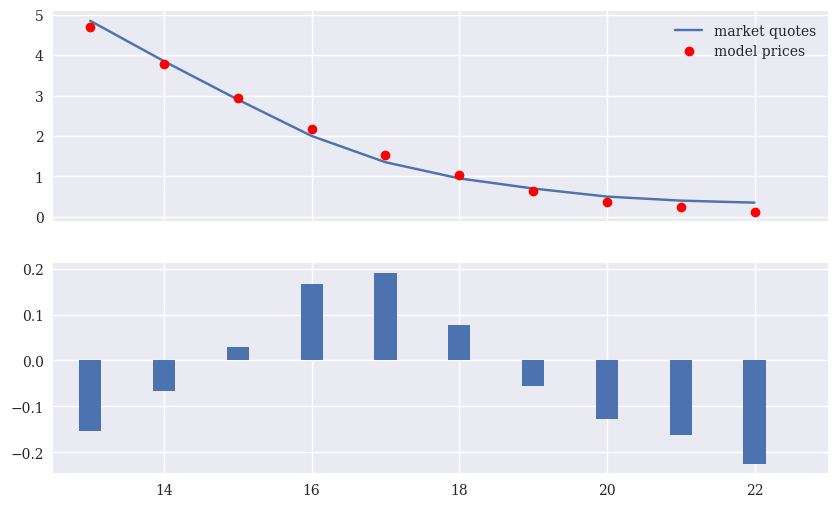

In [38]:
## selecting the data for the shortest maturity
os = option_data[option_data.MATURITY == '2014-4-18']
## selecting corresponding strike prices
strikes = os.STRIKE.values
## comparing the model prices with the market quotes
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 6));
ax[0].plot(strikes, os.PRICE.values, label='market quotes');
ax[0].plot(strikes, os.MODEL.values, 'ro', label='model prices');
ax[0].legend()
ax[1].bar(strikes, os.MODEL.values - os.PRICE.values,
                        width=0.3);
ax[1].set_xlim(12.5, 23);

<p style="font-family: monospace;">Calibration of SRJD model to European call options on the VSTOXX for shortest option maturity (April 2014).

### Two Maturities

Let us proceed with the simultaneous calibration of the model to the May and July maturities. The MSE is also pretty low in this case (i.e. below 0.01).

In [39]:
## read option data, allow for 17.5% moneyness tolerance
option_data = read_select_quotes(tol=0.175)
# option_data

In [40]:
%%time
opt_2 = srjd_model_calibration(option_data, rel=False,
                            mats=['2014-5-16', '2014-7-18'])

/Users/tuan/data/projects/lvvd/code/scripts/srjd_model_calibration.py:123: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  option_data = option_data[option_data['MATURITY'].isin(mats)]



  its  kappa  theta  sigma   lamb     mu  delta         MSE     min_MSE
    0  1.000 10.000  1.000  0.000 -0.200  0.000     8.71137     8.71137
  100  1.000 20.000  3.000  0.800 -0.200  0.150     0.81090     0.10351
  200  5.000 20.000  3.000  0.400 -0.200  0.300     0.54407     0.09015
  300  9.000 20.000  3.000  0.000  0.100  0.000     0.45081     0.01539

  its  kappa  theta  sigma   lamb     mu  delta         MSE     min_MSE
    0  5.000 20.000  3.000  0.800  0.400  0.000     0.01539     0.01539
  100  4.471 19.655  3.256  0.762  0.424  0.000     0.00892     0.00892
  200  4.010 19.231  2.730  0.761  0.575  0.002     0.00792     0.00792
  300  4.023 18.987  2.321  0.721  0.668  0.003     0.01182     0.00688
  400  3.803 18.830  2.115  0.722  0.701  0.003     0.00660     0.00660
  500  3.823 18.799  2.106  0.723  0.706  0.003     0.00644     0.00644
  600  3.998 18.681  1.916  0.728  0.749  0.003     0.00598     0.00598
CPU times: user 2.96 s, sys: 14.5 ms, total: 2.97 s
Wall time:

/Users/tuan/data/projects/lvvd/code/scripts/srjd_model_calibration.py:139: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = sco.fmin(srjd_error_function, p0,


  100  4.471 19.655  3.256  0.762  0.424  0.000     0.00892     0.00892


  200  4.010 19.231  2.730  0.761  0.575  0.002     0.00792     0.00792


...

  400  3.803 18.830  2.115  0.722  0.701  0.003     0.00660     0.00660


  500  3.823 18.799  2.106  0.723  0.706  0.003     0.00644     0.00644


  600  3.998 18.681  1.916  0.728  0.749  0.003     0.00598     0.00598


CPU times: user 3.16 s, sys: 876 ms, total: 4.03 s
Wall time: 3.12 s


/Users/tuan/data/projects/lvvd/code/scripts/srjd_model_calibration.py:139: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = sco.fmin(srjd_error_function, p0,


The optimal parameter values are:

In [41]:
opt_2

array([ 3.99997568, 18.68368075,  1.9167921 ,  0.72829882,  0.748261  ,
        0.00326197])

In what follows, we use the Python function ``plot_calibration_results()`` to generate the plots for the different valuation runs. This function allows for different numbers of sub-plots, i.e. when the number of option maturities is changed. It is mainly a generalization of the plotting code used above.

In [42]:
srjdc.plot_calibration_results??

Signature: srjdc.plot_calibration_results(option_data, opt, mats)
Source:   
def plot_calibration_results(option_data, opt, mats):
    ''' Function to plot market quotes vs. model prices.

    Parameters
    option_data: pandas DataFrame object
        option data to plot
    opt: list
        optimal results from calibration
    mats: list
        maturities to be plotted
    '''
    kappa, theta, sigma, lamb, mu, delta = opt
    # adding model values for optimal parameter set
    # to the DataFrame object
    values = []
    for i, option in option_data.iterrows():
        value = srjd_call_valuation(v0, kappa, theta, sigma,
                                    lamb, mu, delta,
                                    option['TTM'], r, option['STRIKE'],
                                    M=M, I=I, fixed_seed=True)
        values.append(value)
    option_data['MODEL'] = values

    # plotting the market and model values
    height = min(len(mats) * 3, 12)
    fig, axarr = plt.subplots(len(

The following figure shows the results of the  calibration graphically. It is obvious that the SRJD model is able to account for multiple maturities at the same time which is mainly due to the term structure component introduced by the deterministic shift approach.

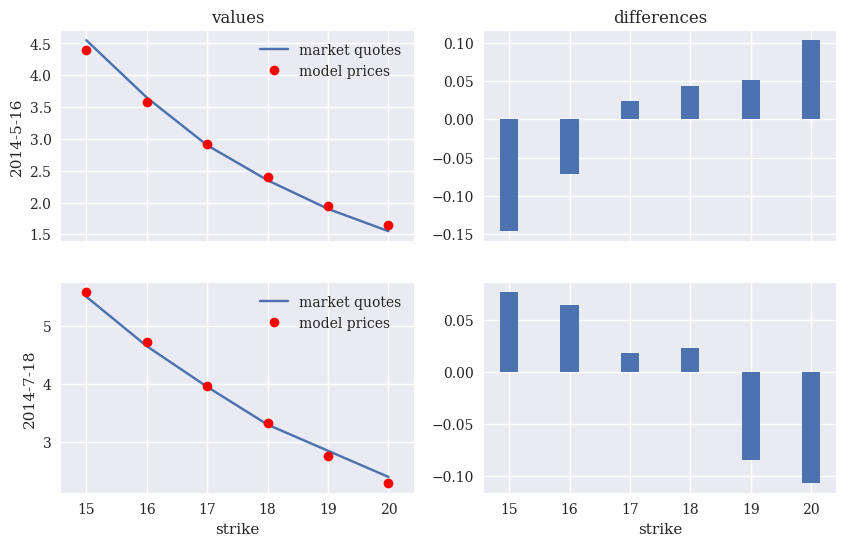

In [43]:
plot_calibration_results(option_data, opt_2, ['2014-5-16', '2014-7-18'])

<p style="font-family: monospace;">Calibration of SRJD model to European call options on the VSTOXX for May and July 2014 maturities.

### Four Maturities

In a next step, we consider four maturities &mdash; before we try to calibrate the model to all eight maturities.

In [44]:
mats = sorted(set(option_data['MATURITY']))
mats

[Timestamp('2014-04-18 00:00:00'),
 Timestamp('2014-05-16 00:00:00'),
 Timestamp('2014-06-20 00:00:00'),
 Timestamp('2014-07-18 00:00:00'),
 Timestamp('2014-08-15 00:00:00'),
 Timestamp('2014-09-19 00:00:00'),
 Timestamp('2014-10-17 00:00:00'),
 Timestamp('2014-11-21 00:00:00')]

The four maturities for this particular calibration run are:

In [45]:
mats[::2]

[Timestamp('2014-04-18 00:00:00'),
 Timestamp('2014-06-20 00:00:00'),
 Timestamp('2014-08-15 00:00:00'),
 Timestamp('2014-10-17 00:00:00')]

For this calibration run, we use the optimal parameters from the previous calibration to two maturities. Obviously, the more options to calibrate the model to, the longer the procedure takes.

In [46]:
%%time
opt_4 = srjd_model_calibration(option_data, p0=opt_2,
                               rel=False, mats=mats[::2])


  its  kappa  theta  sigma   lamb     mu  delta         MSE     min_MSE
    0  4.000 18.684  1.917  0.728  0.748  0.003     0.52345     0.52345
  100  4.202 18.938  1.980  0.727  0.623  0.003     0.27887     0.27681
  200  3.650 21.465  3.293  0.744 -0.075  0.002     0.18617     0.18617
  300  3.195 22.481  2.867  0.743 -0.223  0.000     0.14915     0.14915
  400  3.107 22.191  2.990  0.745 -0.141  0.000     0.14609     0.14608
  500  3.081 22.162  3.028  0.743 -0.138  0.000     0.14572     0.14570
  600  3.057 22.100  3.041  0.738 -0.124  0.000     0.14521     0.14521
CPU times: user 4.29 s, sys: 17.2 ms, total: 4.31 s
Wall time: 4.03 s


/Users/tuan/data/projects/lvvd/code/scripts/srjd_model_calibration.py:139: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = sco.fmin(srjd_error_function, p0,


  400  3.107 22.191  2.990  0.745 -0.141  0.000     0.14609     0.14608


  500  3.081 22.162  3.028  0.743 -0.138  0.000     0.14572     0.14570


  600  3.057 22.100  3.041  0.738 -0.124  0.000     0.14521     0.14521


CPU times: user 4.4 s, sys: 19.1 ms, total: 4.42 s
Wall time: 4.17 s


/Users/tuan/data/projects/lvvd/code/scripts/srjd_model_calibration.py:139: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = sco.fmin(srjd_error_function, p0,


In [47]:
opt_4

array([ 3.06114516, 22.11025139,  3.03389738,  0.73811505, -0.12580616,
        0.00000125])

Even calibrating the model to four maturities yields quite a good fit over these maturities as the following figure illustrates.

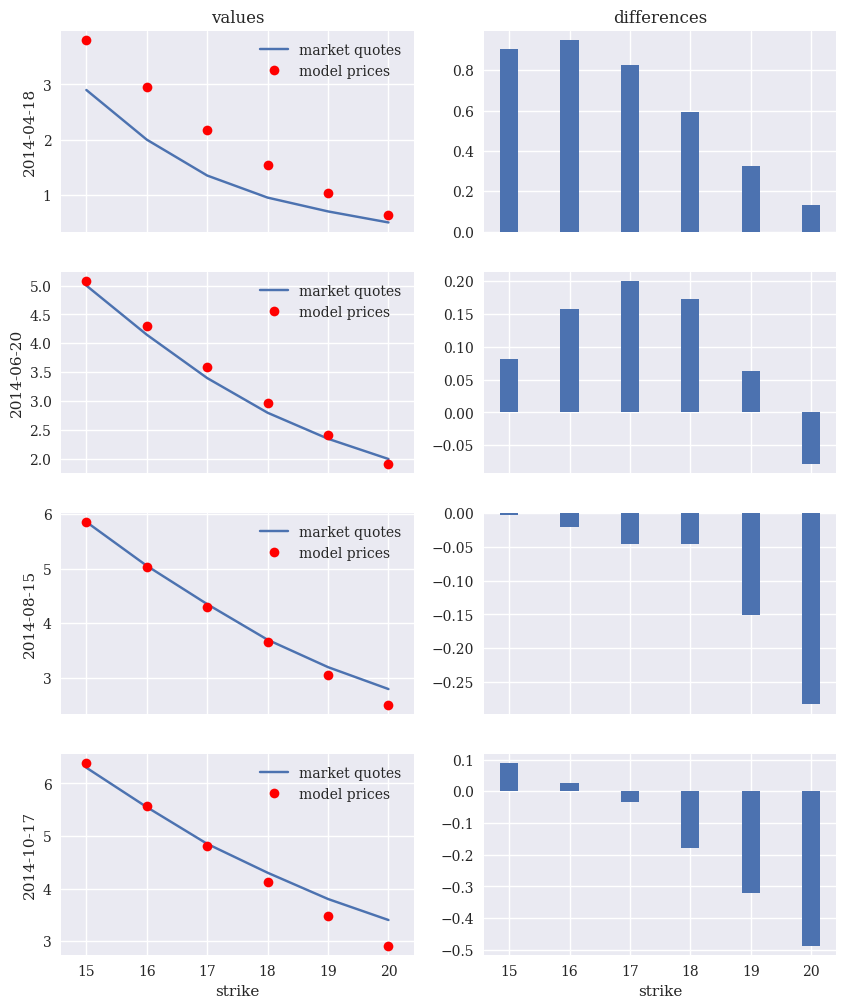

In [48]:
plot_calibration_results(option_data, opt_4, mats[::2])

<p style="font-family: monospace;">Calibration of SRJD model to European call options on the VSTOXX for four maturities.

### All Maturities

Finally, let us attack the hardest calibration problem &mdash; the one involving all eight option maturities.

In [49]:
%%time
opt_8_MSAE = srjd_model_calibration(option_data,
                                rel=False, mats=mats)


  its  kappa  theta  sigma   lamb     mu  delta         MSE     min_MSE
    0  1.000 10.000  1.000  0.000 -0.200  0.000    12.79035    12.79035
  100  1.000 20.000  3.000  0.800 -0.200  0.150     0.91164     0.13849
  200  5.000 20.000  3.000  0.400 -0.200  0.300     1.00115     0.13849
  300  9.000 20.000  3.000  0.000  0.100  0.000     1.27175     0.13849

  its  kappa  theta  sigma   lamb     mu  delta         MSE     min_MSE
    0  1.000 20.000  3.000  0.400  0.400  0.150     0.13849     0.13849
  100  1.007 20.567  2.921  0.396  0.326  0.155     0.12039     0.11935
  200  1.018 21.609  3.266  0.404  0.032  0.163     0.10182     0.10096
  300  1.033 22.713  3.222  0.407 -0.123  0.155     0.09869     0.09863
  400  1.542 23.755  3.235  0.409 -0.985  0.067     0.08329     0.08120
  500  1.860 23.848  2.967  0.410 -1.297  0.002     0.07686     0.07686
  600  1.868 23.863  2.956  0.410 -1.303 -0.000  1000.07683     0.07683
CPU times: user 11.7 s, sys: 52.5 ms, total: 11.8 s
Wall time:

/Users/tuan/data/projects/lvvd/code/scripts/srjd_model_calibration.py:139: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = sco.fmin(srjd_error_function, p0,



  its  kappa  theta  sigma   lamb     mu  delta         MSE     min_MSE
    0  1.000 20.000  3.000  0.400  0.400  0.150     0.13849     0.13849


  100  1.007 20.567  2.921  0.396  0.326  0.155     0.12039     0.11935


  200  1.018 21.609  3.266  0.404  0.032  0.163     0.10182     0.10096


...

  400  1.542 23.755  3.235  0.409 -0.985  0.067     0.08329     0.08120


  500  1.860 23.848  2.967  0.410 -1.297  0.002     0.07686     0.07686


  600  1.868 23.863  2.956  0.410 -1.303 -0.000  1000.07683     0.07683


CPU times: user 12.1 s, sys: 52.2 ms, total: 12.1 s
Wall time: 12.1 s


/Users/tuan/data/projects/lvvd/code/scripts/srjd_model_calibration.py:139: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = sco.fmin(srjd_error_function, p0,


In [50]:
opt_8_MSAE

array([ 1.86781293, 23.86259517,  2.95539873,  0.41015864, -1.30281337,
        0.00000008])

The following shows that the fit is still reasonable for eight maturities and that many options.

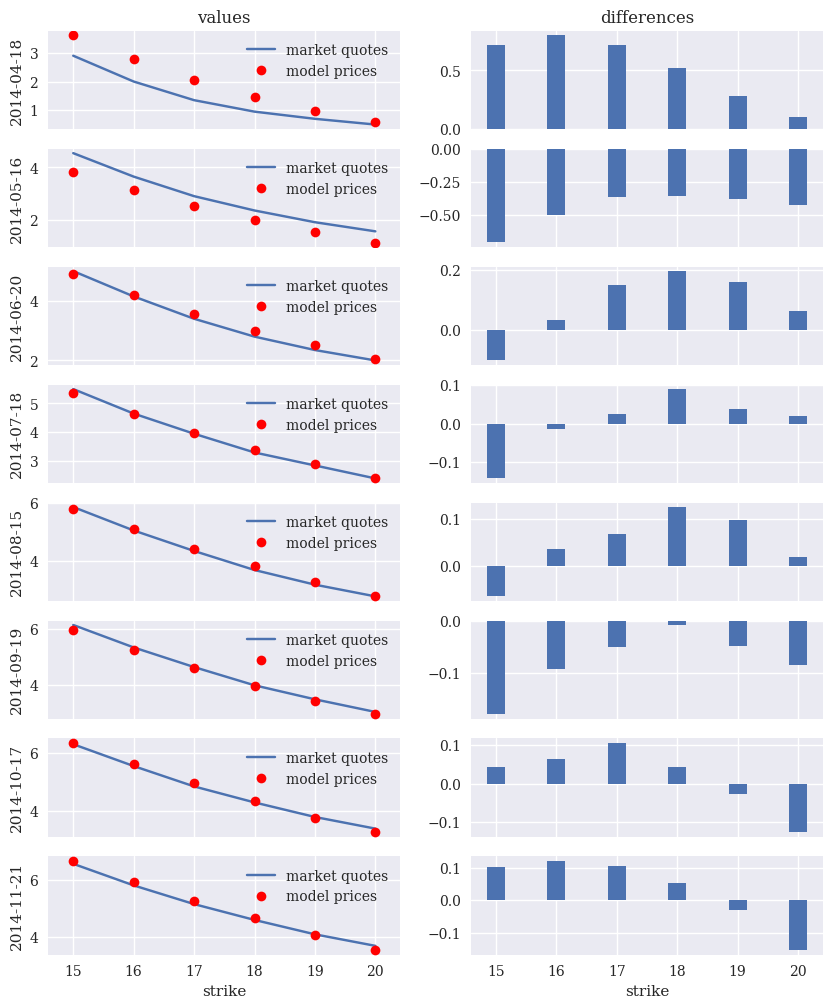

In [51]:
plot_calibration_results(option_data, opt_8_MSAE, mats)

<p style="font-family: monospace;">Calibration of SRJD model to European call options on the VSTOXX for all eight maturities (MSAE used).

To check whether there is a (larger) difference when we calibrate the model using relative differences (i.e. the MSRE) as yardstick, consider the following calibration run.

In [52]:
%%time
opt_8_MSRE = srjd_model_calibration(option_data, p0=opt_8_MSAE,
                                    rel=True, mats=mats)


  its  kappa  theta  sigma   lamb     mu  delta         MSE     min_MSE
    0  1.868 23.863  2.955  0.410 -1.303  0.000     0.02551     0.02551
  100  1.599 24.888  2.619  0.392 -1.381  0.000     0.02099     0.02099
  200  1.015 26.443  2.737  0.388 -1.676  0.000     0.02017     0.02017
  300  0.915 27.147  2.723  0.388 -1.947  0.000     0.02046     0.02011
  400  0.920 27.175  2.719  0.388 -2.142  0.000     0.02010     0.02010
  500  0.927 27.082  2.724  0.389 -2.373  0.000     0.02009     0.02009
  600  0.925 27.083  2.722  0.389 -2.409  0.000     0.02009     0.02009
CPU times: user 7.98 s, sys: 30.6 ms, total: 8.01 s
Wall time: 8.07 s


/Users/tuan/data/projects/lvvd/code/scripts/srjd_model_calibration.py:139: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = sco.fmin(srjd_error_function, p0,


  400  0.920 27.175  2.719  0.388 -2.142  0.000     0.02010     0.02010


  500  0.927 27.082  2.724  0.389 -2.373  0.000     0.02009     0.02009


  600  0.925 27.083  2.722  0.389 -2.409  0.000     0.02009     0.02009


CPU times: user 7.95 s, sys: 11 ms, total: 7.97 s
Wall time: 7.97 s


/Users/tuan/data/projects/lvvd/code/scripts/srjd_model_calibration.py:139: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = sco.fmin(srjd_error_function, p0,


The following figure presents the results. They are not too dissimular to the ones obtained using the MSAE as yardstick. The major difference is the weighting of the options in that now those options with lower market quotes (higher strikes) get more weight.

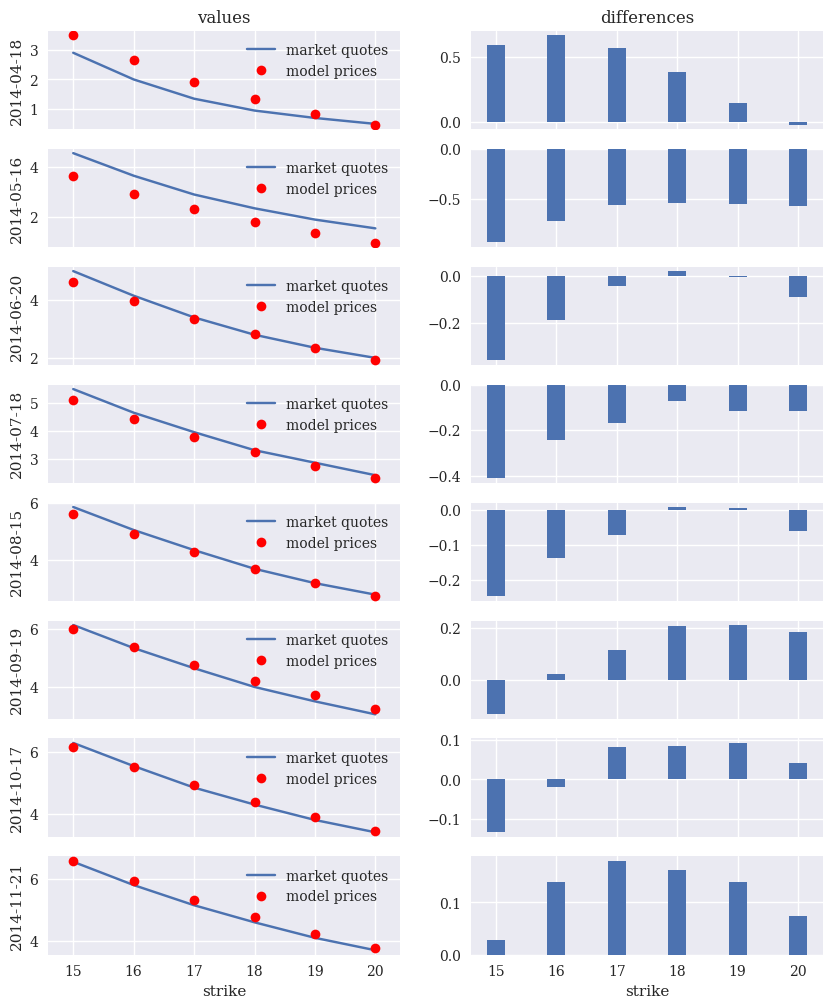

In [53]:
plot_calibration_results(option_data, opt_8_MSRE, mats)

<p style="font-family: monospace;">Calibration of SRJD model to European call options on the VSTOXX for all eight maturities (MSRE used).

## Conclusions

This chapter introduces a more sophisticated model, the so-called square-root jump diffusion model (SRJD), for the evolution of the VSTOXX volatility index over time. It enhances the Gruenbichler and Longstaff (1996) square-root diffusion model by two components: a log normally distributed *jump component* and a *determistic shift component*. While the first allows to better calibrate the model to short term option quotes, the latter makes it possible to take the volatility term structure &mdash; as embodied by the eight futures on the VSTOXX index &mdash; into account. All in all, the model yields good calibration results even in cases where all eight option maturities are accounted for.

## Python Scripts

### srjd_fwd_calibration.py

In [54]:
!cat scripts/srjd_fwd_calibration.py

#
# Script for term structure calibration of
# Square-Root Jump Diffusion (SRJD) model
#
# (c) Dr. Yves J. Hilpisch
# Listed Volatility and Variance Derivatives
#
import math
import numpy as np
import pandas as pd
import scipy.optimize as sco

v0 = 17.6639  # initial VSTOXX index level
i = 0  # counter for calibration runs

# reading the VSTOXX futures quotes
path = './data/'
h5 = pd.HDFStore(path + 'vstoxx_data_31032014.h5', 'r')
futures_quotes = h5['futures_data']
h5.close()

# selecting needed data columns and adding spot value
forwards = list(futures_quotes['PRICE'].values)
forwards.insert(0, v0)
forwards = np.array(forwards)
ttms = list(futures_quotes['TTM'].values)
ttms.insert(0, 0)
ttms = np.array(ttms)


def srd_forwards(p0):
    ''' Function for forward volatilities in GL96 Model.

    Parameters
    p0: list
        set of model parameters, where

        kappa: float
            mean-reversion factor
        theta: float
            long-run mean
        sigma: float
       

### srjd_simulation.py 

In [55]:
!cat scripts/srjd_simulation.py

#
# Module with simulation functions for
# Square-Root Jump Diffusion (SRJD) model
#
# (c) Dr. Yves J. Hilpisch
# Listed Volatility and Variance Derivatives
#
import math
import pickle
import numpy as np
import scipy.interpolate as scint

v0 = 17.6639  # initial VSTOXX index level

# parameters of square-root diffusion
kappa = 2.0  # speed of mean reversion
theta = 15.0  # long-term volatility
sigma = 1.0  # standard deviation coefficient

# parameters of log-normal jump
lamb = 0.4  # intensity (jumps per year)
mu = 0.4  # average jump size
delta = 0.1  # volatility of jump size

# general parameters
r = 0.01  # risk-free interest rate
K = 17.5  # strike
T = 0.5  # time horizon
M = 150  # time steps
I = 10000  # number of MCS paths
anti_paths = True  # antithetic variates
mo_match = True  # moment matching


# deterministic shift parameters
varphi = pickle.load(open('varphi', 'rb'))
tck = scint.splrep(varphi['ttms'], varphi['varphi'], k=1)
  # linear splines interpolation of
  # term s

### srjd_model_calibration.py

In [56]:
!cat scripts/srjd_model_calibration.py

#
# Calibration of square-root jump diffusion (SRJD) model
# to VSTOXX European call options traded at Eurex
# Data as of 31. March 2014
# All data from www.eurexchange.com
#
# (c) Dr. Yves J. Hilpisch
# Listed Volatility and Variance Derivatives
#
import numpy as np
import pandas as pd
import scipy.optimize as sco
import matplotlib.pyplot as plt
from srd_model_calibration import path, read_select_quotes
from srjd_simulation import srjd_call_valuation

# fixed parameters
r = 0.01  # risk-less short rate
v0 = 17.6639  # VSTOXX index at 31.03.2014
M = 15  # number of time intervals
I = 100  # number of simulated paths


def srjd_valuation_function(p0):
    ''' Valuation ('difference') function for all options
        of a given DataFrame object.

    Parameters
    p0: list
        set of model parameters

    Returns
    diffs: NumPy ndarray object
        array with valuation differences
    '''
    global relative, option_data
    kappa, theta, sigma, lamb, mu, delta = p0
    diffs = 

<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:team@tpq.io">team@tpq.io</a>